# Exploratory Data Analysis 
## Using International Coastal Cleanup Data
### OES 805 - Data Science

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading raw data
infile = '/Users/ariellenogueira/Desktop/Data Science/OEAS805/HW2/Data/International_Coastal_Cleanup.csv'
data = pd.read_csv(infile, sep = ',' , low_memory = False)

In [3]:
# get information about the data
data.shape

(77, 53)

In [4]:
data.dtypes

Area                                          object
Date                                          object
Cigarette Butts                               object
Food Wrappers (candy, chips, etc.)            object
Take Out/Away Containers (Plastic)             int64
Take Out/Away Containers (Foam)                int64
Bottle Caps (Plastic)                          int64
Bottle Caps (Metal)                           object
Lids (Plastic)                                 int64
Straws, Stirrers                               int64
Forks, Knives, Spoons                          int64
Beverage Bottles (Plastic)                     int64
Beverage Bottles (Glass)                      object
Beverage Cans                                  int64
Grocery Bags (Plastic)                         int64
Other Plastic Bags                             int64
Paper Bags                                     int64
Cups, Plates (Paper)                           int64
Cups, Plates (Plastic)                        

#### Based on these categories, it seems like something cool to do would be fitting them into broader categories like plastic, paper, and foam, or even medical vs foodstuff.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     object 
 1   Date                                       77 non-null     object 
 2   Cigarette Butts                            77 non-null     object 
 3   Food Wrappers (candy, chips, etc.)         77 non-null     object 
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     object 
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons       

#### Looking at this, I'm noticing that each item has a count of 77 and I'm a little stuck on that. So I want to look again at how this data is laid out. 

In [6]:
data.describe()

,Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,...,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Foam Pieces,Number of Volunteers,Volunteer Hours,Number of Miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,18.363636,13.714286,98.337662,23.350649,50.558442,13.909091,68.922078,44.350649,38.961039,36.233766,...,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,64.441558,18.896104,37.37013,1.530909
std,21.944253,18.943724,148.793093,26.738877,62.141920,20.238825,92.227089,55.825331,59.709922,77.109269,...,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,128.515767,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,1.000000,16.000000,6.000000,11.000000,1.000000,15.000000,6.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,9.00000,1.000000
50%,8.000000,6.000000,43.000000,13.000000,24.000000,7.000000,34.000000,26.000000,17.000000,10.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,14.000000,11.000000,22.00000,1.000000
75%,31.000000,19.000000,107.000000,33.000000,72.000000,20.000000,70.000000,67.000000,44.000000,34.000000,...,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,58.000000,22.000000,38.00000,2.000000
max,90.000000,106.000000,780.000000,109.000000,368.000000,136.000000,395.000000,276.000000,326.000000,542.000000,...,7.000000,441.000000,33.000000,24.000000,15.00000,14.000000,750.000000,178.000000,396.00000,10.000000


#### It seems like the data is laid out by a count of the different items in each area. Let's put this into some categories and start actually looking at the data.

In [7]:
# isolate the trash categories 
# there's probably a better way to do this but this is the only way I can think of

item_columns = [
    col 
    for col in data.columns 
    if col not in [
        'Total Items Collected', 
        'Total Pounds of Litter Collected', 
        'Number of Volunteers', 
        'Volunteer Hours', 
        'Number of Miles', 
        'Area', 
        'Date'
    ]
]

# this sum function didn't want to work before but I think I can convert items to numeric since there might be commas

for col in item_columns:
    data[col] = (
        data[col].astype(str).str.replace(",","")
    ) 
    data[col]=pd.to_numeric(data[col],errors="coerce").fillna(0)

top_items = data[item_columns].sum().sort_values(ascending=False).head(10)
print(top_items)



Cigarette Butts                       36975.0
Plastic Pieces                        20577.0
Bottle Caps (Metal)                   18894.0
Food Wrappers (candy, chips, etc.)    11875.0
Glass Pieces                           9206.0
Bottle Caps (Plastic)                  7572.0
Beverage Bottles (Plastic)             5307.0
Foam Pieces                            4962.0
Straws, Stirrers                       3893.0
Beverage Bottles (Glass)               3464.0
dtype: float64


### Now let's make a plot!

/var/folders/pz/mv3lk6493c3d161lj9s5xqvh0000gn/T/ipykernel_31289/3241112233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette="mako")


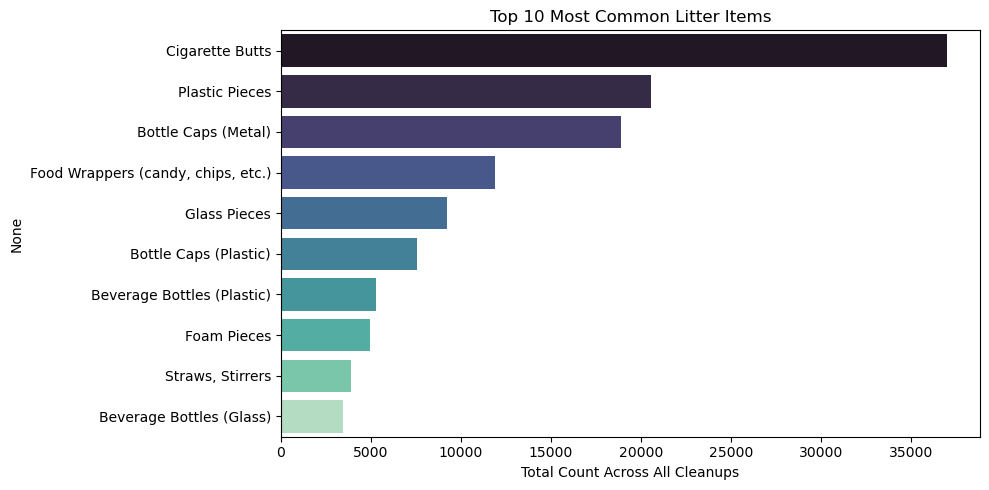

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_items.values, y=top_items.index, palette="mako")
plt.title("Top 10 Most Common Litter Items")
plt.xlabel("Total Count Across All Cleanups")
plt.tight_layout()
plt.show()

### Now I want to look at the comparison between locations

In [9]:
# have to do the text replacement again
data["Total Items Collected"] = (
    data["Total Items Collected"].astype(str).str.replace(",","")
)
data["Total Items Collected"] = pd.to_numeric(
    data["Total Items Collected"], errors="coerce"
).fillna(0)

top_locations = (
    data.groupby('Area')['Total Items Collected']
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

print(top_locations)

Area
Barraud Park                                       66041.5
Harbor Park (ERT)                                  15528.0
Ocean View Beach Park                              13876.0
Willoughby Spit                                     8729.0
Lambert's Point (ODU Service Learning Group)        7892.0
Lafayette Park & Lavalette Boat Ramp                5229.0
East Ocean View (1300 - 1800 Block)                 4904.0
East Ocean View                                     4110.0
Norfolk Collegiate (Lafayette Park - Boat Ramp)     4037.0
Lakewood Park                                       3963.0
Name: Total Items Collected, dtype: float64


### Make another plot for this.

/var/folders/pz/mv3lk6493c3d161lj9s5xqvh0000gn/T/ipykernel_31289/787986647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette="rocket")


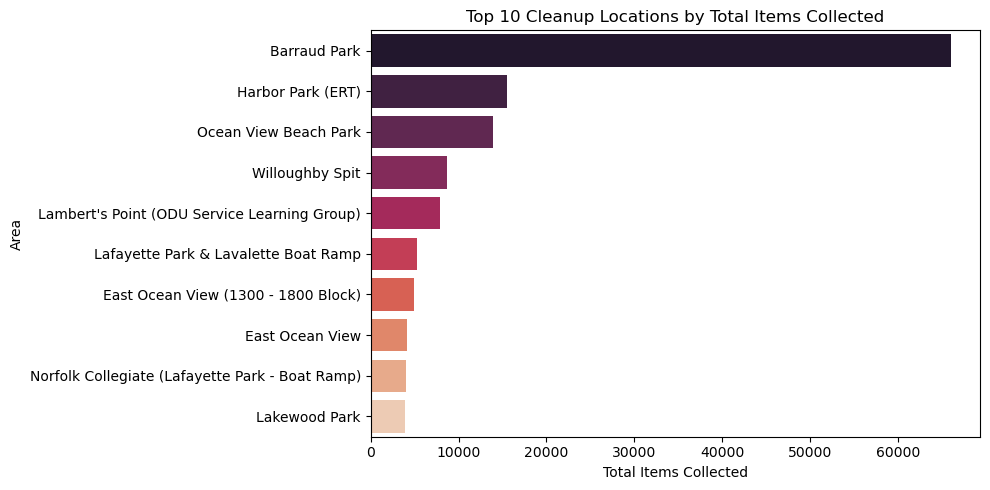

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="rocket")
plt.title("Top 10 Cleanup Locations by Total Items Collected")
plt.xlabel("Total Items Collected")
plt.tight_layout()
plt.show()

### I realized after some more experimentation that a lot of the variables are still stored as text?

In [11]:
summary_cols = [
    "Total Pounds of Litter Collected",
    "Number of Volunteers",
    "Volunteer Hours",
    "Number of Miles",
]

for col in summary_cols:
    data[col] = data[col].astype(str).str.replace(",","")
    data[col] = pd.to_numeric(data[col], errors = "coerce").fillna(0)

print("Yay! Data has been cleaned!")

Yay! Data has been cleaned!


## Descriptive Statistics

In [12]:
key_vars = [
    "Total Items Collected",
    "Total Pounds of Litter Collected",
    "Number of Volunteers",
    "Volunteer Hours",
    "Number of Miles",
    ]

desc_stats = data[key_vars].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]

desc_stats[["mean","std","min","25%","50%","75%","max","IQR"]]

,mean,std,min,25%,50%,75%,max,IQR
Total Items Collected,2059.474026,3408.767664,0.0,337.0,851.0,1936.0,20544.0,1599.0
Total Pounds of Litter Collected,200.558442,379.650445,0.0,30.0,80.0,180.0,2545.0,150.0
Number of Volunteers,18.896104,27.249135,0.0,5.0,11.0,22.0,178.0,17.0
Volunteer Hours,37.370130,57.043520,0.0,9.0,22.0,38.0,396.0,29.0
Number of Miles,1.530909,1.486711,0.0,1.0,1.0,2.0,10.0,1.0


### Visualizations

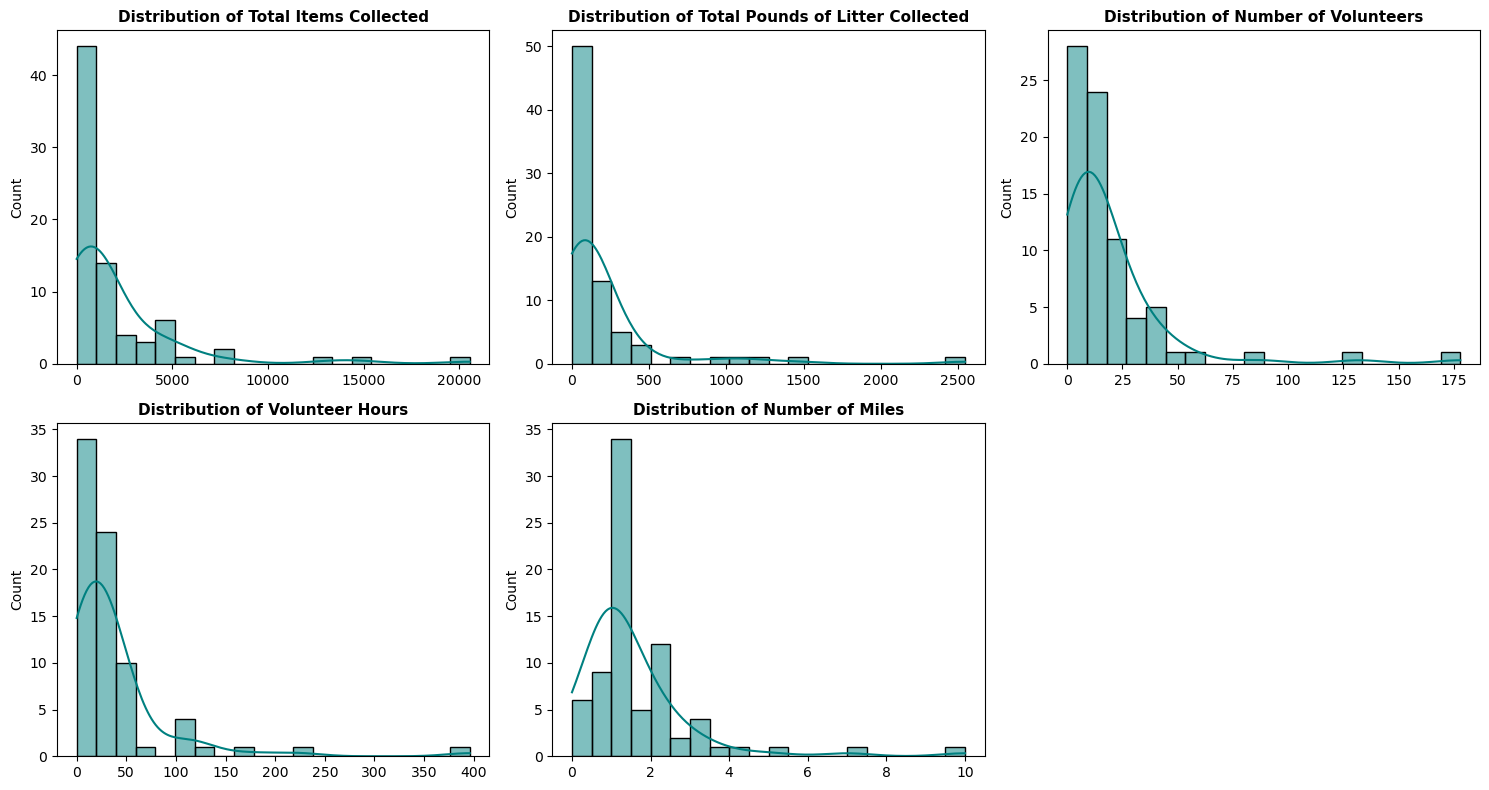

In [13]:
fig, axes = plt.subplots(2,3,figsize=(15,8))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.histplot(data[var], kde=True, ax=axes[i], color="teal", bins=20)
    axes[i].set_title(f"Distribution of {var}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")

axes[5].axis("off")
plt.tight_layout()
plt.show()

### Statistical Analysis to Identify Outliers

In [14]:
for var in key_vars:
    q1 = data[var].quantile(0.25)
    q3 = data[var].quantile(0.75)
    iqr = q3-q1
    threshold = q3 + 1.5 * iqr
    outliers = data[data[var] > threshold]
    print(
        f"{var}: Outlier Count = {len(outliers)}"
    )

Total Items Collected: Outlier Count = 12
Total Pounds of Litter Collected: Outlier Count = 7
Number of Volunteers: Outlier Count = 5
Volunteer Hours: Outlier Count = 8
Number of Miles: Outlier Count = 4


#### Outlier Boxplot

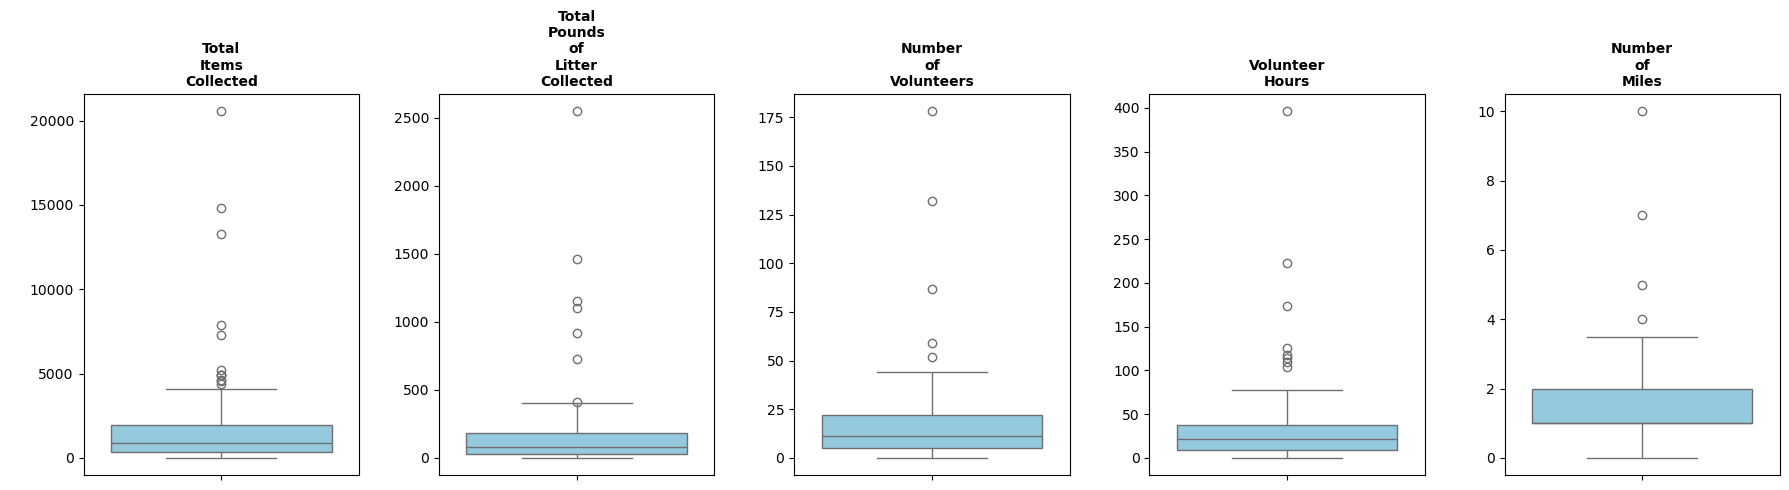

In [15]:
fig, axes = plt.subplots(1,5,figsize=(18,5))
for i, var in enumerate(key_vars):
    sns.boxplot(y=data[var], ax=axes[i], color="skyblue")
    axes[i].set_title(var.replace(" ","\n"), fontsize=10,fontweight="bold")
    axes[i].set_ylabel(" ")

plt.tight_layout()
plt.show()

#### This plot makes the skew and outliers very visible, they are all skewed right (which would be expected for this type of data) with some very high outliers from locations where anomalous amounts of trash were collected.

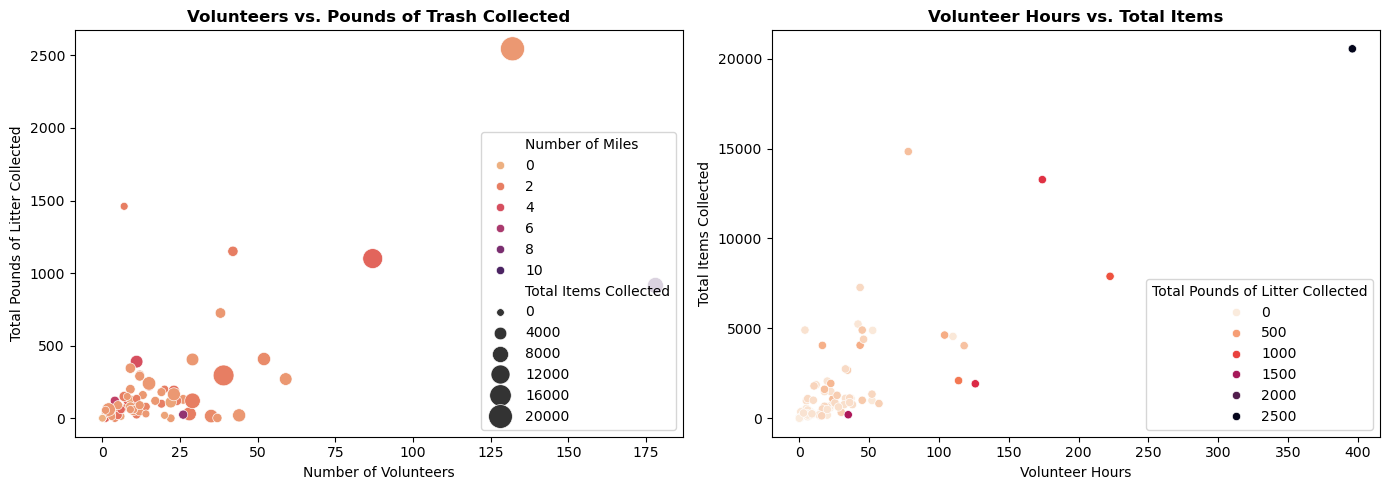

In [16]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# volunteers vs weight
sns.scatterplot(
    data=data,
    x= "Number of Volunteers",
    y= "Total Pounds of Litter Collected",
    hue= "Number of Miles",
    size= "Total Items Collected",
    sizes=(30, 300),
    ax=axes[0],
    palette="flare"
)
axes[0].set_title(
    "Volunteers vs. Pounds of Trash Collected", fontsize=12, fontweight="bold"
)

# hours vs items
sns.scatterplot(
    data=data,
    x= "Volunteer Hours",
    y= "Total Items Collected",
    hue= "Total Pounds of Litter Collected",
    ax=axes[1],
    palette="rocket_r"
)
axes[1].set_title(
    "Volunteer Hours vs. Total Items", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()

## One more thing I want to do is look at the litter by material type.

/var/folders/pz/mv3lk6493c3d161lj9s5xqvh0000gn/T/ipykernel_31289/3473461860.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mat_df.values, y=mat_df.index, palette="pastel")


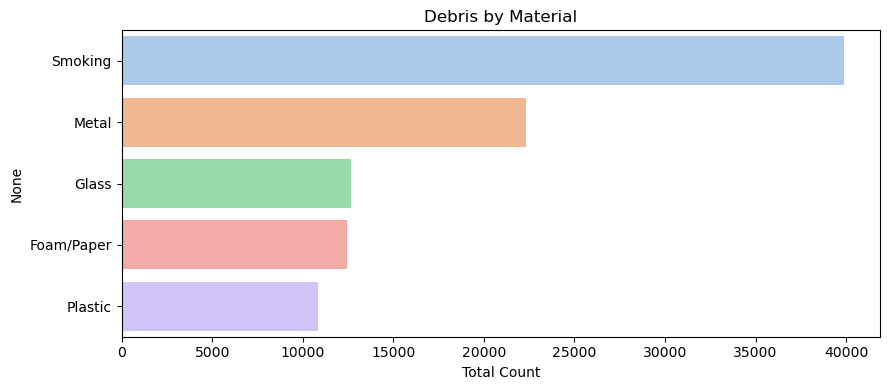

In [17]:
materials = {
    "Plastic":[
        c
        for c in item_columns
        if "plastic" in c or "Straws" in c or "Bags" in c],
    "Glass":[c 
             for c in item_columns 
             if "Glass" in c],
    "Metal":[c 
             for c in item_columns 
             if "Metal" in c or "Cans" in c],
    "Foam/Paper":[c 
            for c in item_columns 
            if "Foam" in c or "Paper" in c or "Cardboard" in c],
    "Smoking":[c 
            for c in item_columns 
            if "Cigarette" in c or "Tobacco" in c],
}

material_totals = {}
for mat, cols in materials.items():
    valid_cols = [c for c in cols if c in data.columns]
    material_totals[mat] = data[valid_cols].sum().sum()

mat_df = pd.Series(material_totals).sort_values(ascending=False)

plt.figure(figsize=(9,4)
          )
sns.barplot(x=mat_df.values, y=mat_df.index, palette="pastel")
plt.title("Debris by Material")
plt.xlabel("Total Count")
plt.tight_layout()
plt.show()
    

## Conclusions
#### All of these metrics are skewed right, which makes the median a much better metric than the mean.
#### Volunteer hours are much more important than mileage in terms of the amount of litter collected.
#### A great deal of the litter was made up of smoking waste, which can be helpful to inform prevention tactics.